In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle

import subcluster_funcs as funcs
sc._settings.settings._vector_friendly=True

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)

In [3]:
cell_type = "Endothelial"

In [4]:
adata = sc.read_h5ad("../post_subclustering/" + cell_type  + ".h5ad")

<Axes: xlabel='leiden', ylabel='sil_score'>

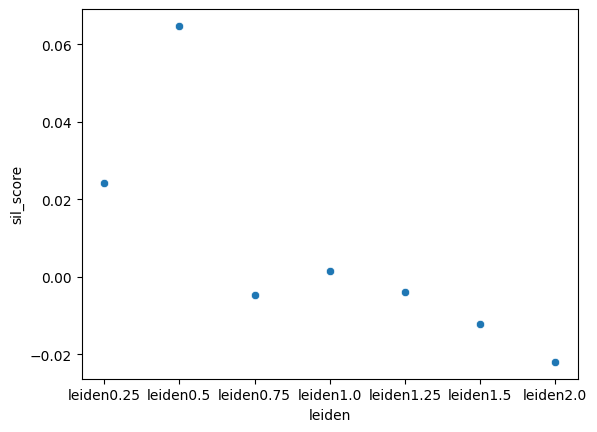

In [5]:
funcs.silhouette(adata, cell_type = cell_type)

### Leiden 0.1 only results in 2 clusters, which may be too restrictive

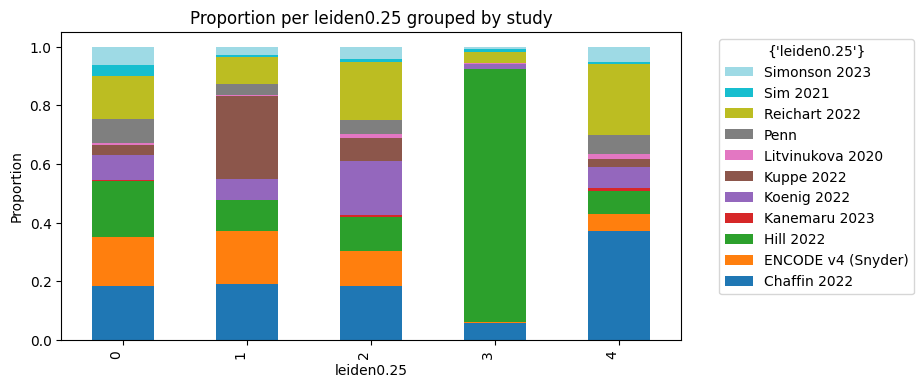

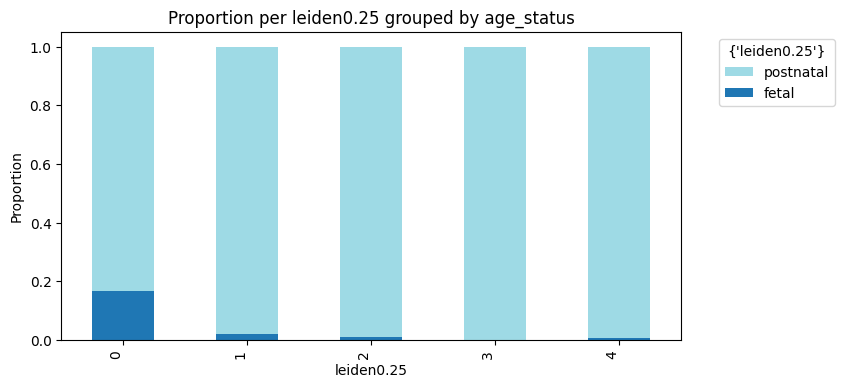

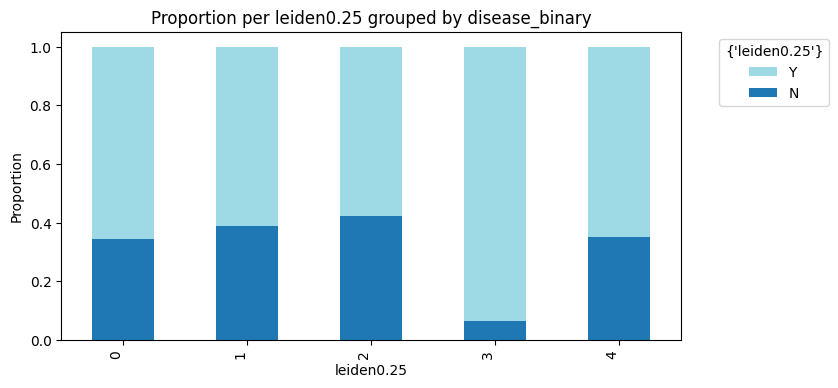

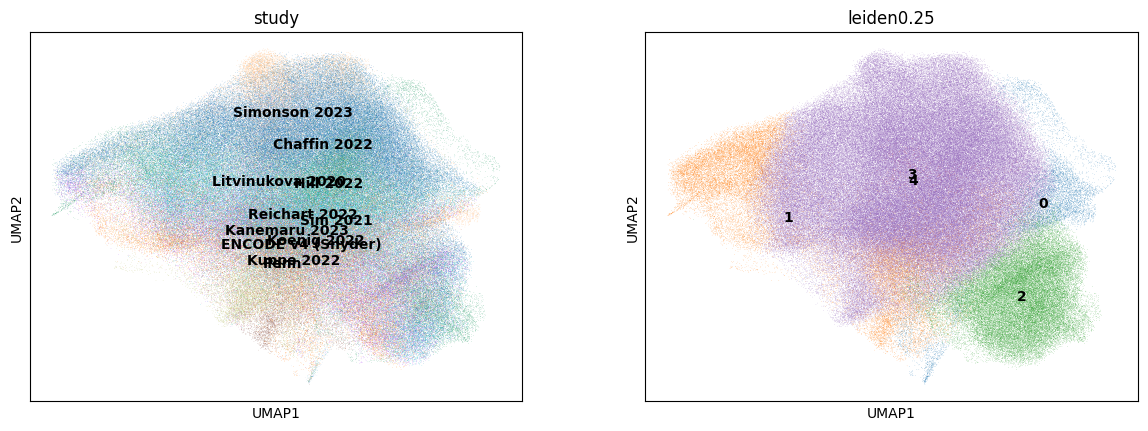

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean

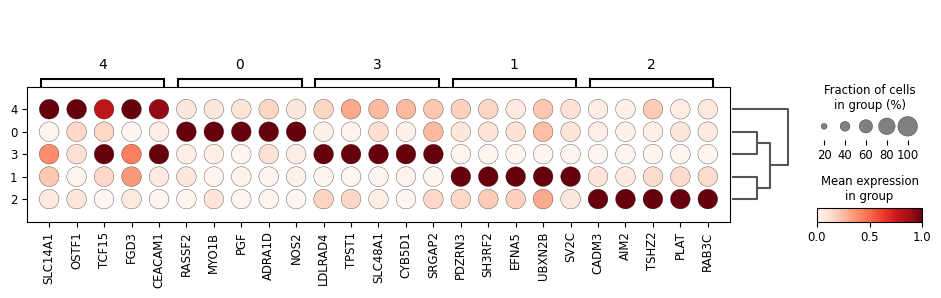

Counter({'4': 227080, '2': 45553, '1': 34171, '0': 9602, '3': 718})


['leiden0.25',
 AnnData object with n_obs × n_vars = 317124 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0'
     var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0', 'neighbors', 'pca', 'rank_genes_groupsleiden0.1', 'rank_genes_groupsleiden0.25', 'rank_genes_groupsleiden0.5', 'rank_genes_groupsleiden0.75', 'rank_genes_groupsleiden1.0', 

In [6]:
funcs.specify_leiden_subclustering(adata=adata, leiden="leiden0.25")

- Cluster 0 are activated endothelial cells (NOS2+, TNFRSF4, TNFRSF18)
- Cluster 1 are likely arterial cells (PDZRN3,FBN2,EFNA5)
- Cluster 2 are venous (SELE,SELP,NR2F2)
- Cluster 3 is a very small cluster, primarily in one study, but most similar to capillary
- Cluster 4 are microvascular cells (CEACAM1/CXCL17/CD300LG)

In [7]:
#sc.pl.umap(adata, color = ["PRDM16"], cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True))

In [8]:
sc.get.rank_genes_groups_df(adata, group="1").head(40)['names']

0       PDZRN3
1       SH3RF2
2        EFNA5
3       UBXN2B
4         SV2C
5       MOGAT1
6        NRXN1
7       HOMER2
8       RASSF4
9         CAP2
10      LONRF2
11       L1CAM
12      CARNS1
13      INPP5J
14        FBN2
15        IRF6
16    SLC22A15
17       NLGN1
18        SPEG
19       ARNT2
20       PTPN3
21         FLG
22       WDR35
23         TOX
24       ERBB4
25       CNTN3
26      TFAP2A
27       EPDR1
28          HR
29     PIP5K1B
30      ACOT11
31       MARK1
32    C1orf226
33        GGT7
34        SOX5
35        PLS1
36    KIAA1958
37        TC2N
38     DENND5B
39       PDE3B
Name: names, dtype: object

In [9]:
adata.obs['subcluster'] = adata.obs['leiden0.25'].map(
    {"0": "Activated",
     "1": "Arterial",
     "2": "Venous",
     "3": "Capillary",
     "4": "Capillary",
    }
)

In [10]:
subcluster_order = [
    "Activated",
    "Capillary",
    "Arterial",
    "Venous"]

adata.obs['subcluster'] = pd.Categorical(
    adata.obs['subcluster'], categories=subcluster_order, ordered=True
)

# Define colors for each subcluster
subcluster_colors = {
    "Activated": "yellow",       
    "Capillary": "cyan",     
    "Arterial": "red",
    "Venous": "blue"
}

adata.uns['subcluster_colors'] = [subcluster_colors[sc] for sc in subcluster_order]

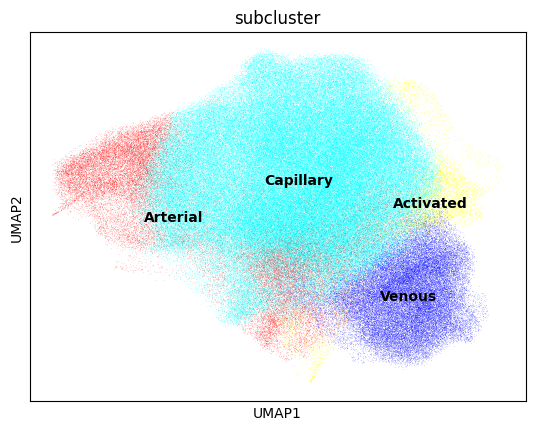

In [11]:
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['subcluster'], legend_loc = "on data", palette=subcluster_colors, show=False)
    plt.savefig("Endo_subclustered.pdf", bbox_inches="tight")

- Cluster 0 are activated endothelial cells (NOS2, TNFRSF4, TNFRSF18)
- Cluster 1 are likely arterial cells (PDZRN3,FBN2,EFNA5)
- Cluster 2 are venous (SELE,SELP,NR2F2)
- Cluster 3 is a very small cluster, primarily in one study
- Cluster 4 are microvascular cells (CEACAM1/CXCL17/CD300LG)

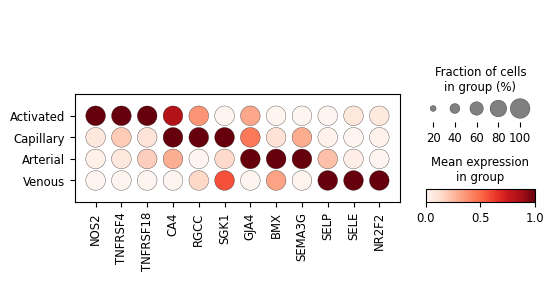

In [23]:
with plt.rc_context(): 
    sc.pl.dotplot(adata, var_names = ["NOS2", "TNFRSF4", "TNFRSF18",
                                       "CA4", "RGCC", "SGK1",
                                       "GJA4", "BMX", "SEMA3G",
                                       "SELP", "SELE", "NR2F2"], 
              groupby = "subcluster", show=False, standard_scale='var', layer="scvi_normalized")
    plt.savefig("Endo_subclustered_dotplot.pdf", bbox_inches="tight")

In [13]:
subcluster_stats = (
    adata.obs['subcluster']
    .value_counts(normalize=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "subcluster"})
)

subcluster_stats["proportion"] = subcluster_stats["count"] / subcluster_stats["count"].sum()

print(subcluster_stats)

  subcluster   count  proportion
0  Capillary  227798    0.718325
1     Venous   45553    0.143644
2   Arterial   34171    0.107753
3  Activated    9602    0.030278
